In [1]:
import os
os.getcwd()

#import os
#os.chdir("..")   # move up one level from Statistical Analysis
#os.chdir("ICM_Distribution_Paper")  # optional if needed

print(os.getcwd())

/Users/johnbryantcadiz/Desktop/GitHub/ICM_Distribution_Paper


In [2]:
import pandas as pd
import numpy as np
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import pingouin as pg
import re

# ==============================================================
# 1. LOAD AND CLEAN DATA  (Corrected header handling)
# ==============================================================

file = "All_Simulation_Data - High Demand 100 km.csv"

# Read the first three rows as header info
header_rows = pd.read_csv(file, nrows=3, header=None)
data = pd.read_csv(file, skiprows=3, header=None)

# Forward-fill missing header cells across columns (horizontal)
header_rows = header_rows.fillna(method="ffill", axis=1)

# Combine 3 rows into one header name per column
combined_headers = []
for i in range(header_rows.shape[1]):
    parts = [str(x).strip() for x in header_rows.iloc[:, i].values if pd.notna(x)]
    combined_headers.append("_".join(parts))

# Assign headers and clean
df = data.copy()
df.columns = combined_headers

# Clean up header typos and spaces
def clean_header(h):
    h = h.replace("Electtricity", "Electricity")
    h = h.replace("Liquiefaction", "Liquefaction")
    h = h.replace("Commpressor", "Compressor")
    h = h.replace("Trans Leage", "Trans Leakage")
    h = h.replace("length", "Length")
    h = h.replace("Cap Cost", "Capital Cost")
    h = h.strip().replace("  ", " ")
    return h

df.columns = [clean_header(c) for c in df.columns]

# Drop empty columns and rows
df = df.dropna(axis=1, how="all")
df = df.dropna(how="all")

print("✅ Header structure fixed.")
print(f"Total columns: {df.shape[1]}")
print("Example flattened headers:", df.columns[:5].tolist())


FileNotFoundError: [Errno 2] No such file or directory: 'All_Simulation_Data - High Demand 100 km.csv'

In [ ]:
cities = ["New Haven", "Fresno", "Atlanta", "Miami"]
modes = ["Gas Truck", "Liquid Truck", "Pipeline"]

for city in cities:
    for mode in modes:
        subset = df.filter(regex=f"{city}.*{mode}", axis=1)
        subset.columns = [c.split("_")[-1] for c in subset.columns]
        nan_summary = subset.isna().sum()
        if nan_summary.any():
            print(f"\n=== {city} - {mode} ===")
            print(nan_summary[nan_summary > 0].sort_values(ascending=False).head(10))

In [ ]:
# ==============================================================
# 2. SETUP VARIABLES
# ==============================================================

cities = ["New Haven", "Fresno", "Atlanta", "Miami"]
modes = ["Gas Truck", "Liquid Truck", "Pipeline"]
results = []

# ------------------------------------------------------
# Helper function to ensure unique column names
# ------------------------------------------------------
def deduplicate(names):
    """Append suffixes (_1, _2, ...) to duplicate column names."""
    seen = {}
    new_names = []
    for name in names:
        if name not in seen:
            seen[name] = 0
            new_names.append(name)
        else:
            seen[name] += 1
            new_names.append(f"{name}_{seen[name]}")
    return new_names


# ==============================================================
# 3. LOOP THROUGH CITY × MODE BLOCKS
# ==============================================================

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)  # silence pingouin's divide warnings

for city in cities:
    for mode in modes:
        subset = df.filter(regex=f"{city}.*{mode}", axis=1)
        if subset.empty:
            print(f"⚠️ No data found for {city} - {mode}")
            continue

        # Simplify to variable names only
        subset.columns = [c.split("_")[-1] for c in subset.columns]

        # Identify target outputs
        outputs = [col for col in subset.columns if "Total Cost" in col or "Total GHG Cost" in col]
        if not outputs:
            print(f"⚠️ Missing outputs in {city} - {mode}")
            continue

        # Define columns to exclude (sub-costs, GHG components)
        excluded_patterns = [
            "Total Cost", "Total GHG Cost",
            "Station Cost", "Delivery Cost", "Distribution Cost", "Transmission Cost",
            "Station GHG Cost", "Delivery GHG Cost", "Distribution GHG Cost", "Transmission GHG Cost"
        ]

        # Keep only independent input variables
        inputs = [col for col in subset.columns if not any(pat in col for pat in excluded_patterns)]

        # Deduplicate *before* selection
        subset.columns = deduplicate(subset.columns)

        for output in outputs:
            if output not in subset.columns:
                print(f"⚠️ {city} - {mode} missing output '{output}' after deduplication.")
                continue

            # Refresh input list to match deduplicated names
            inputs = [c for c in subset.columns if c != output and not any(pat in c for pat in excluded_patterns)]

            # Create clean subset
            subset_clean = subset[inputs + [output]].dropna()
            subset_clean = subset_clean.replace("-", np.nan)

            if subset_clean.shape[0] < 5:
                print(f"⚠️ Skipping {city} - {mode} - {output}: too few valid rows")
                continue

            # ------------------------------------------------------
            # (1) PEARSON & SPEARMAN CORRELATIONS
            # ------------------------------------------------------
            pearson_corr = subset_clean.corr(method="pearson")[output].drop(output)
            spearman_corr = subset_clean.corr(method="spearman")[output].drop(output)

            # ------------------------------------------------------
            # (2) STANDARDIZED REGRESSION COEFFICIENTS (SRC)
            # ------------------------------------------------------
            X = subset_clean[inputs].apply(pd.to_numeric, errors='coerce').dropna(axis=1, how="any")
            y = pd.to_numeric(subset_clean[output], errors='coerce')
            inputs = X.columns.tolist()  # refresh after cleaning

            if len(inputs) < 2:
                print(f"⚠️ {city} - {mode} - {output}: Not enough valid inputs after cleaning.")
                continue

            X_scaled = StandardScaler().fit_transform(X)
            y_scaled = StandardScaler().fit_transform(y.values.reshape(-1, 1)).ravel()
            model = LinearRegression().fit(X_scaled, y_scaled)
            src = pd.Series(model.coef_, index=inputs)

            # ------------------------------------------------------
            # (3) PARTIAL RANK CORRELATION COEFFICIENTS (PRCC)
            # ------------------------------------------------------
            prcc_values = []
            for var in inputs:
                try:
                    prcc = pg.partial_corr(
                        data=subset_clean,
                        x=var,
                        y=output,
                        covar=[v for v in inputs if v != var],
                        method="spearman"
                    )
                    prcc_values.append(prcc["r"].values[0])
                except Exception:
                    prcc_values.append(np.nan)
            prcc = pd.Series(prcc_values, index=inputs)

            # ------------------------------------------------------
            # SAFE COMBINATION (handle duplicates)
            # ------------------------------------------------------
            def safe_reindex(series, cols):
                s = series.copy()
                s = s[~s.index.duplicated()]
                return s.reindex(cols).values

            df_temp = pd.DataFrame({
                "City": city,
                "Mode": mode,
                "Output": output,
                "Variable": inputs,
                "Pearson_r": safe_reindex(pearson_corr, inputs),
                "Spearman_r": safe_reindex(spearman_corr, inputs),
                "SRC": safe_reindex(src, inputs),
                "PRCC": safe_reindex(prcc, inputs)
            })

            results.append(df_temp)


# ==============================================================
# 4. COMBINE RESULTS AND EXPORT
# ==============================================================

if not results:
    raise ValueError("❌ No valid results found. Check column names for Total Cost and Total GHG Cost.")

final_results = pd.concat(results, ignore_index=True)

# Compute absolute values for sorting
for metric in ["Pearson_r", "Spearman_r", "SRC", "PRCC"]:
    final_results[f"abs_{metric}"] = final_results[metric].abs()

final_sorted = final_results.sort_values(
    by=["City", "Mode", "Output", "abs_Pearson_r"],
    ascending=[True, True, True, False]
)

# Auto-name output file
demand_label = "Low"
if "Medium" in file:
    demand_label = "Medium"
elif "High" in file:
    demand_label = "High"

output_file = f"{demand_label}_Demand_Sensitivity_Analysis.csv"
final_sorted.to_csv(output_file, index=False)

print("\n✅ Sensitivity analysis complete.")
print(f"📁 Saved as '{output_file}'")
print("Columns:", list(final_sorted.columns))


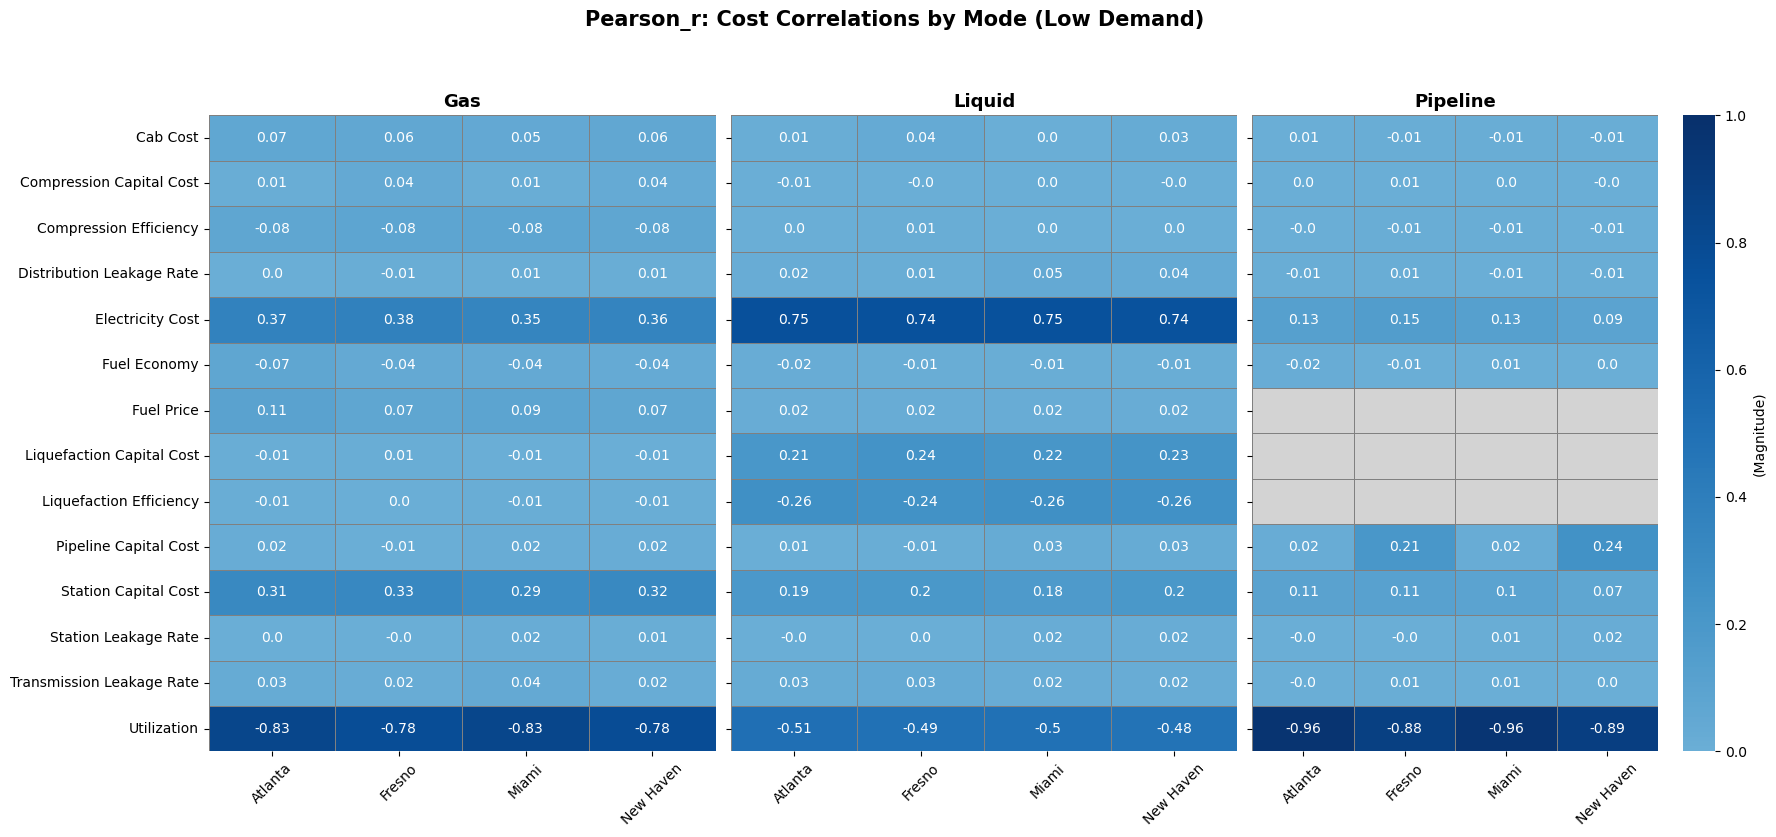

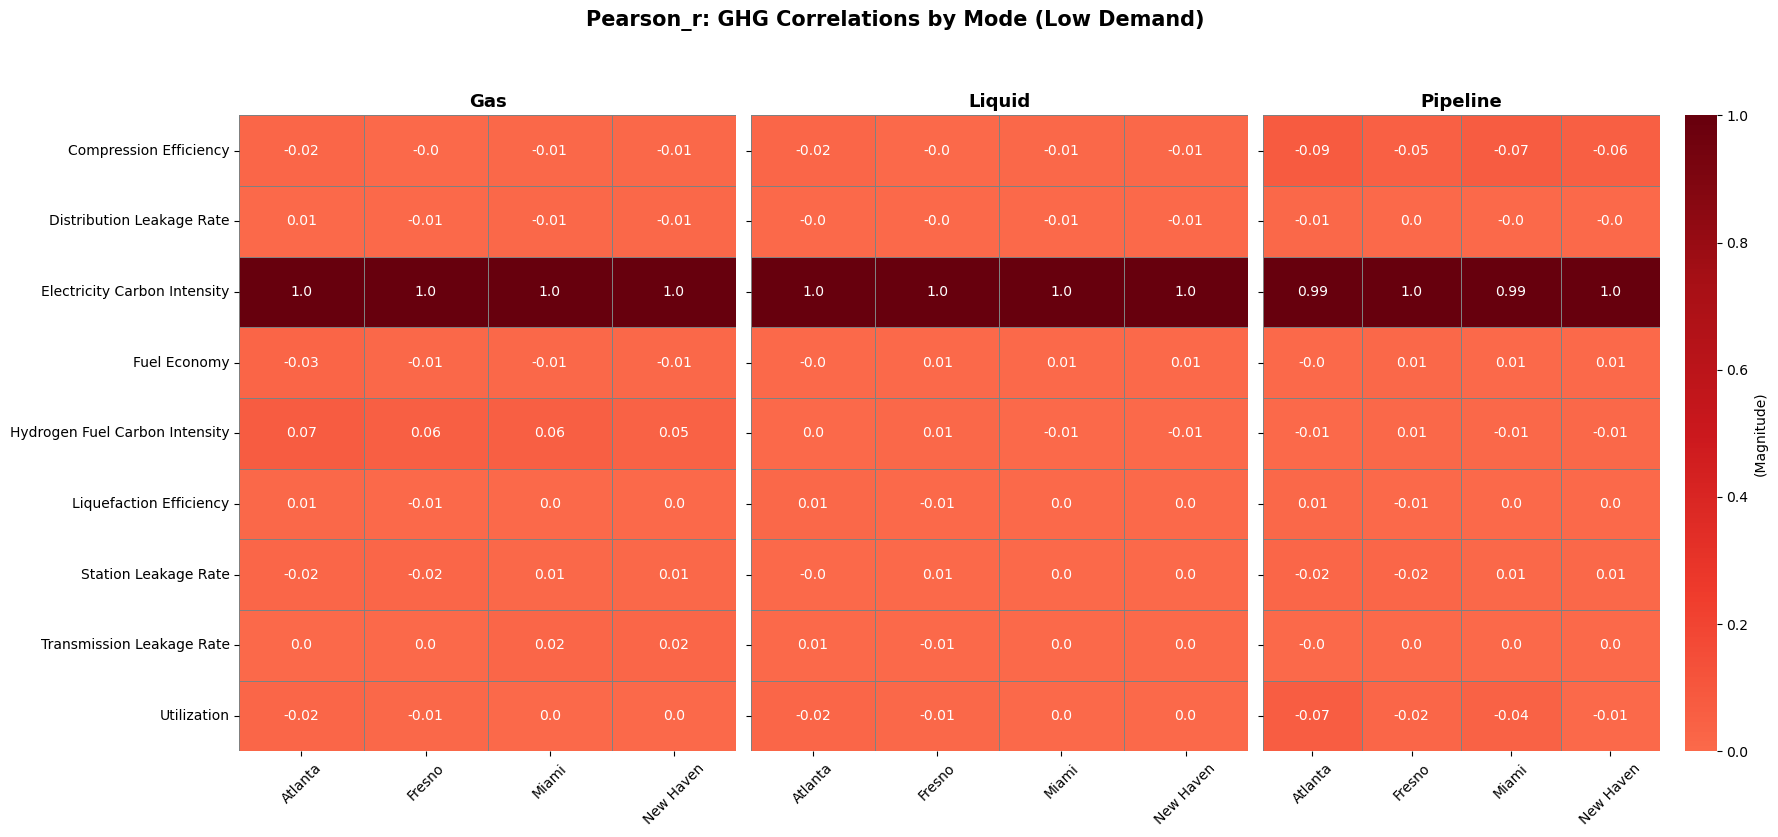

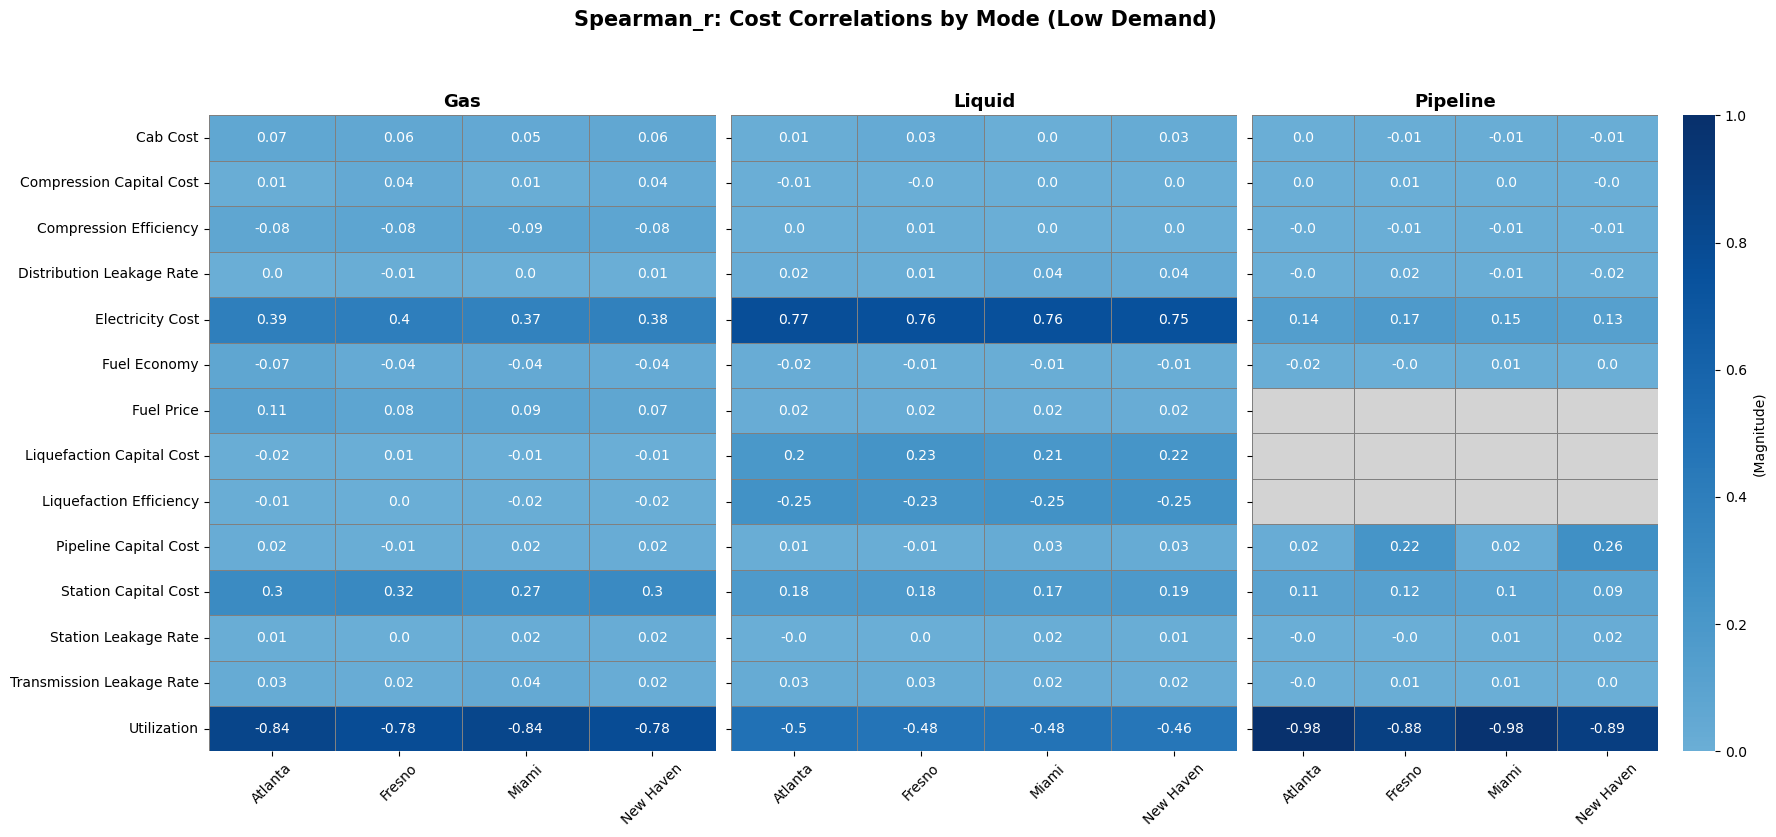

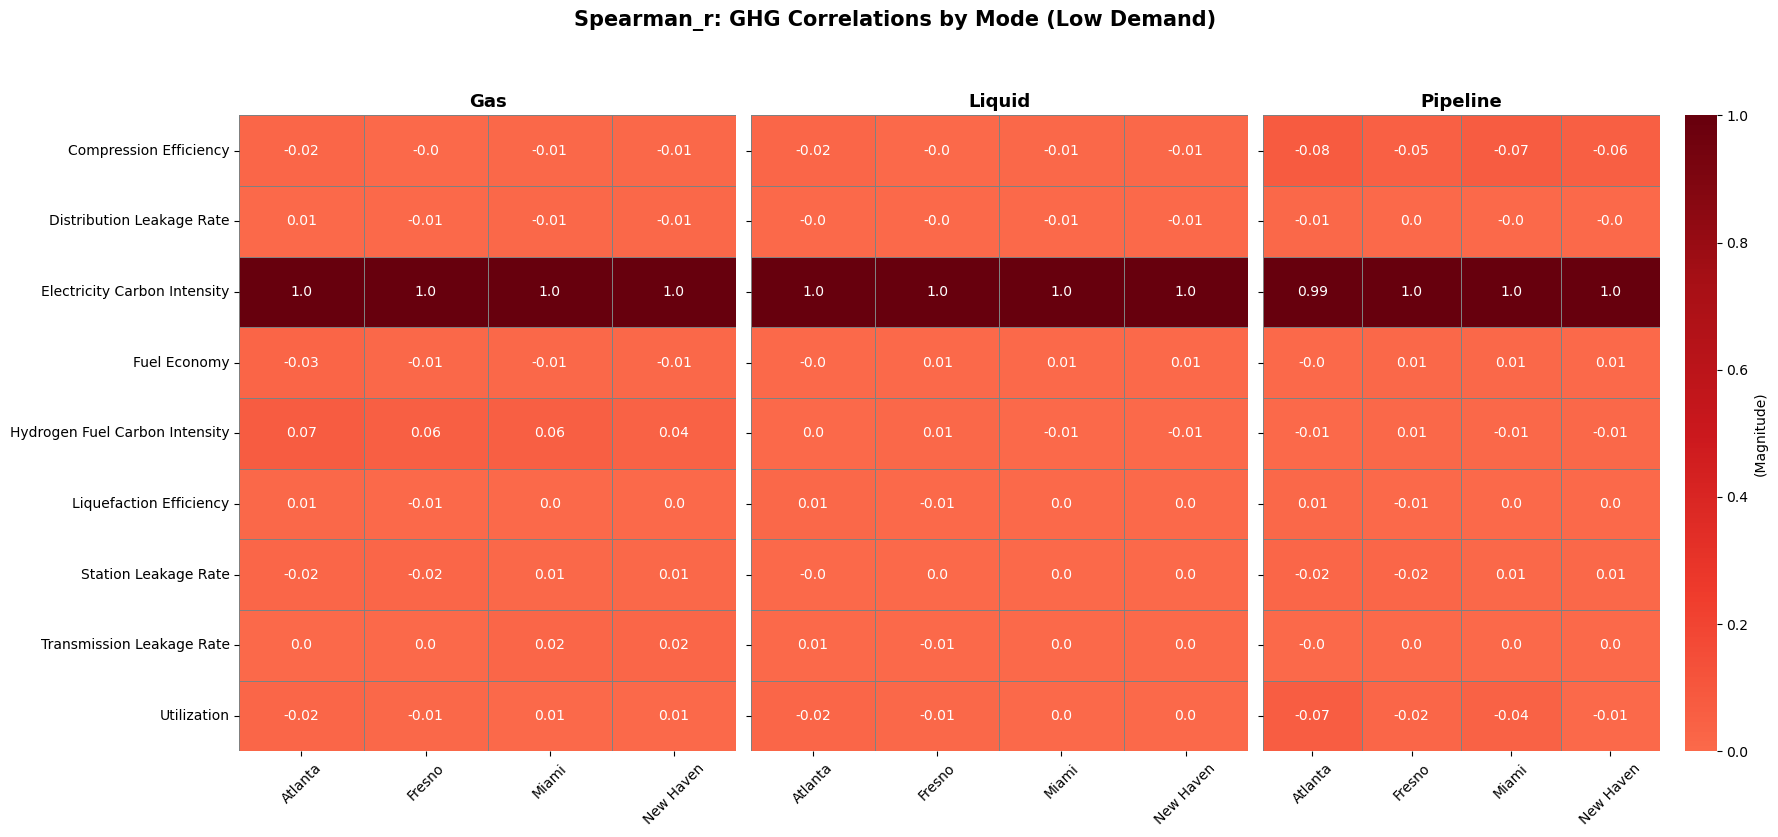

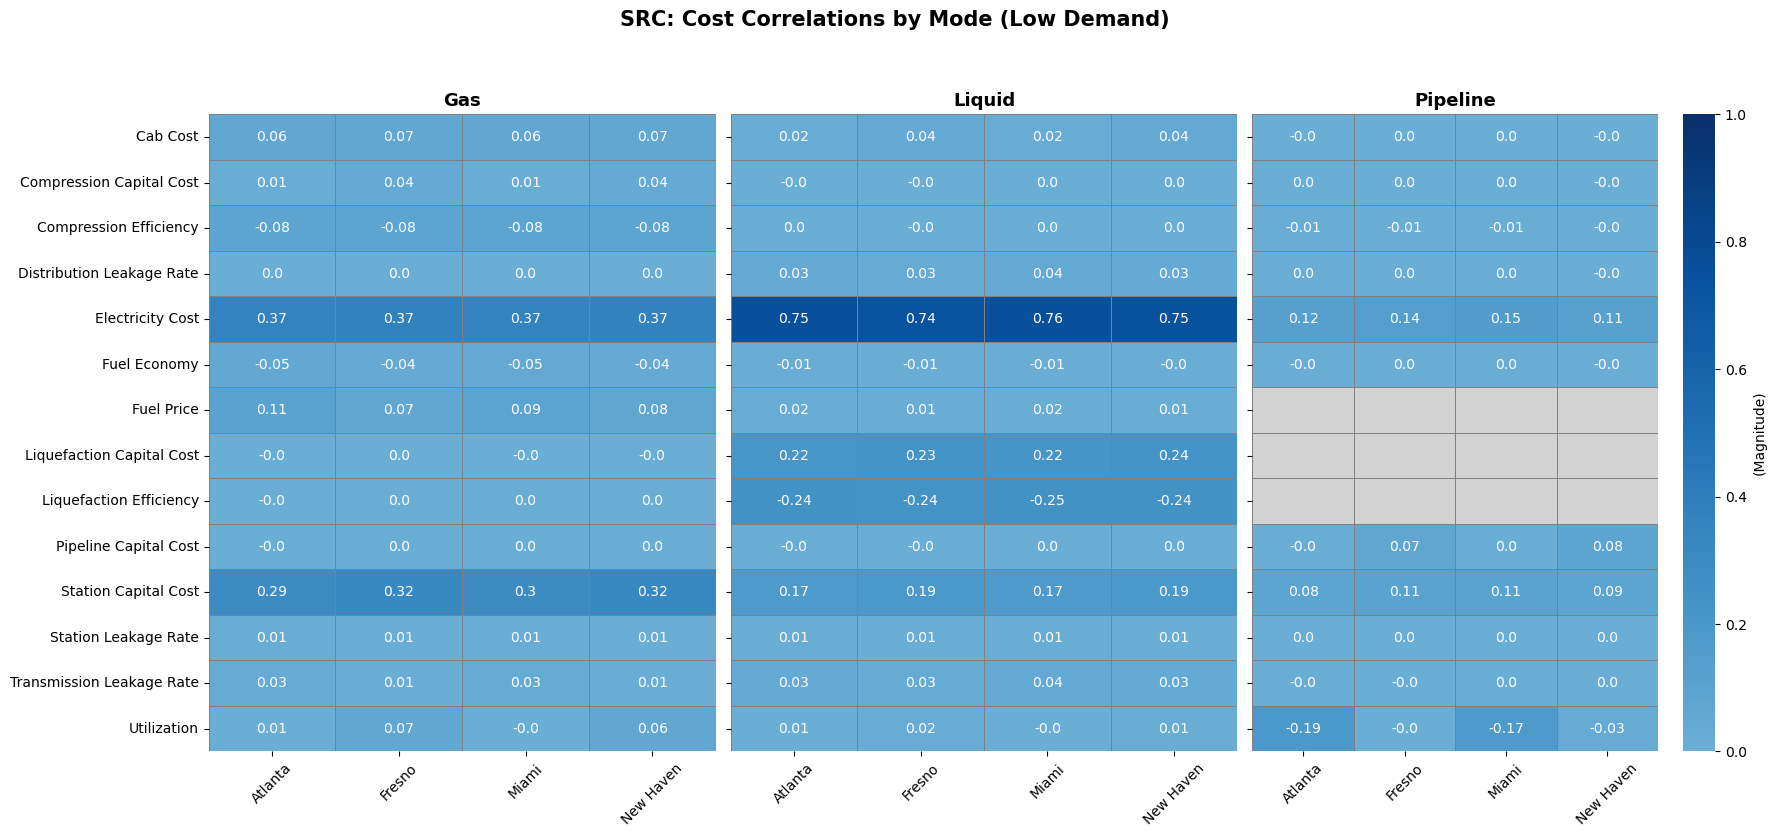

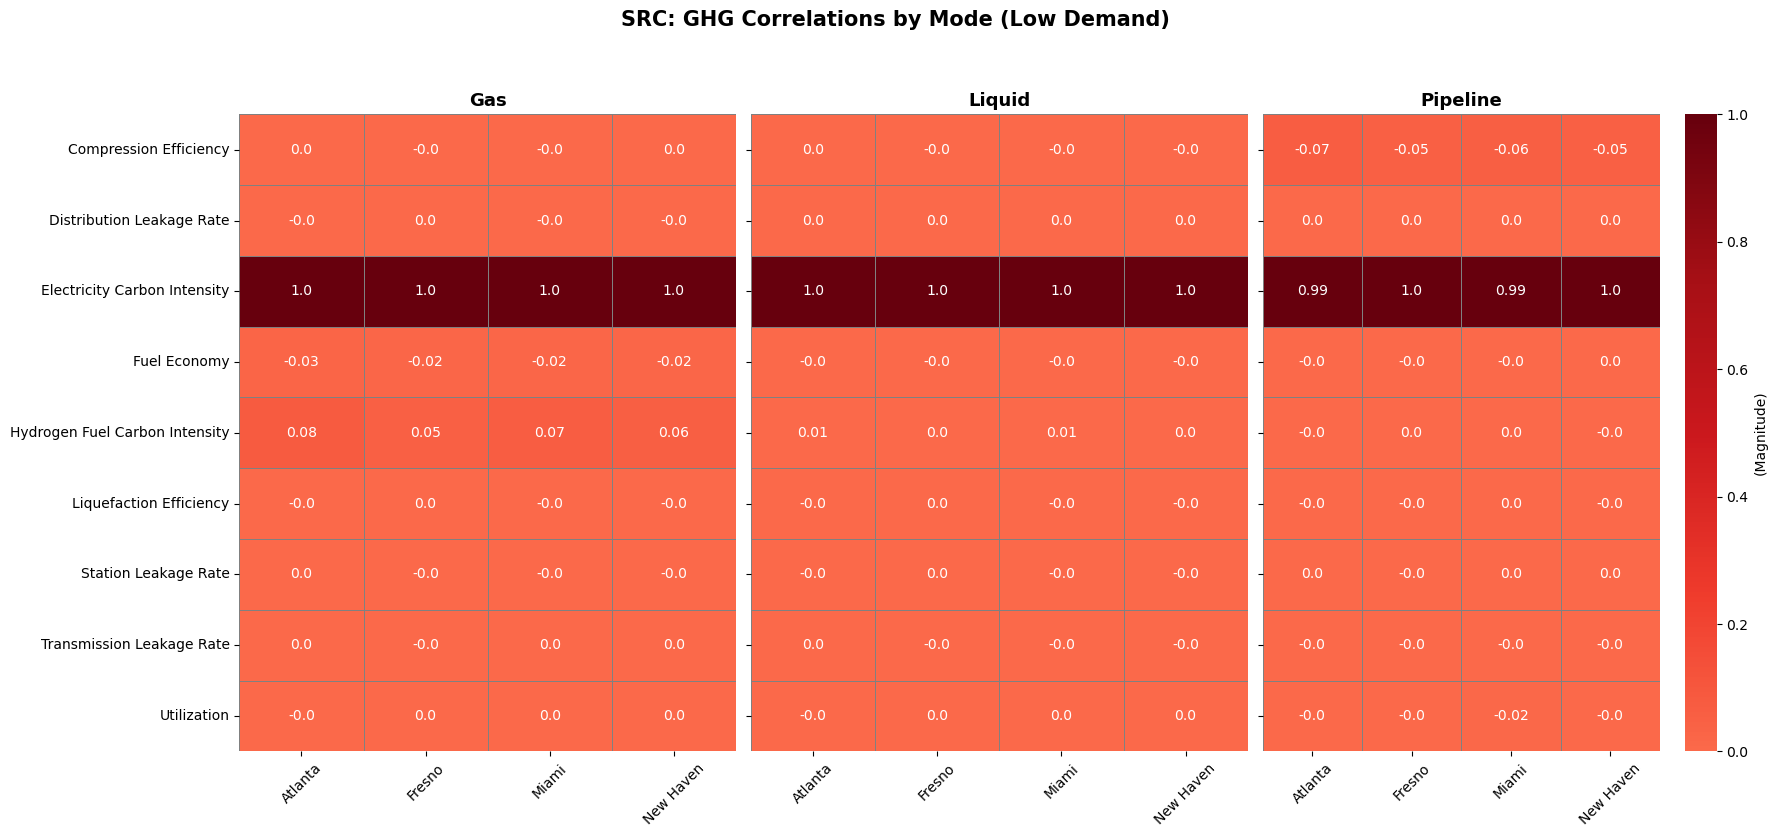

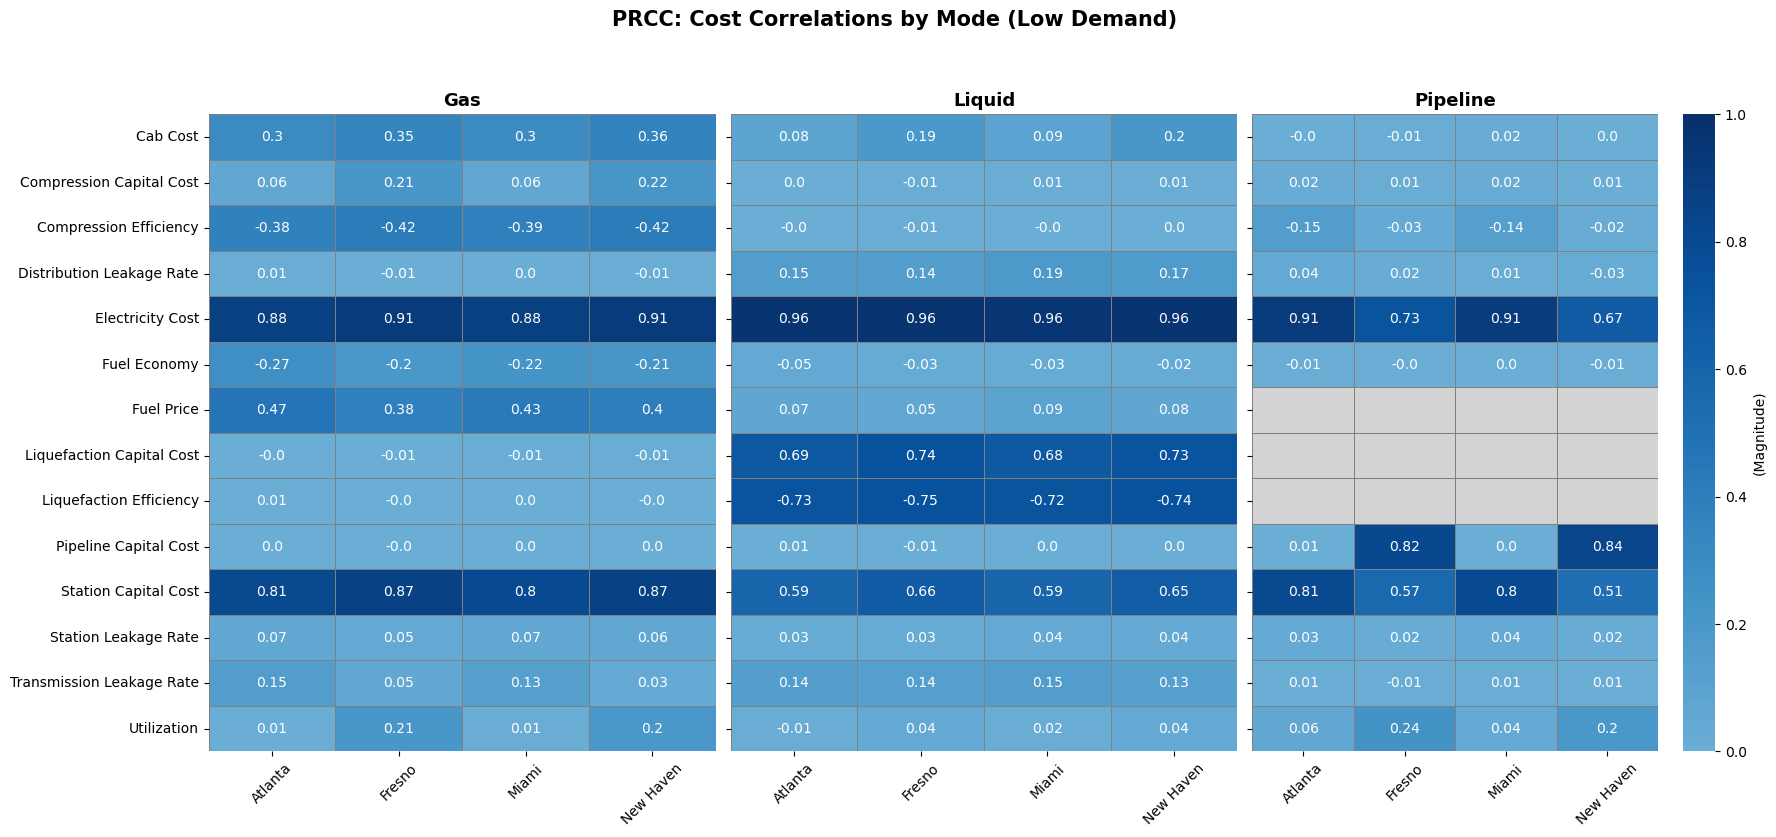

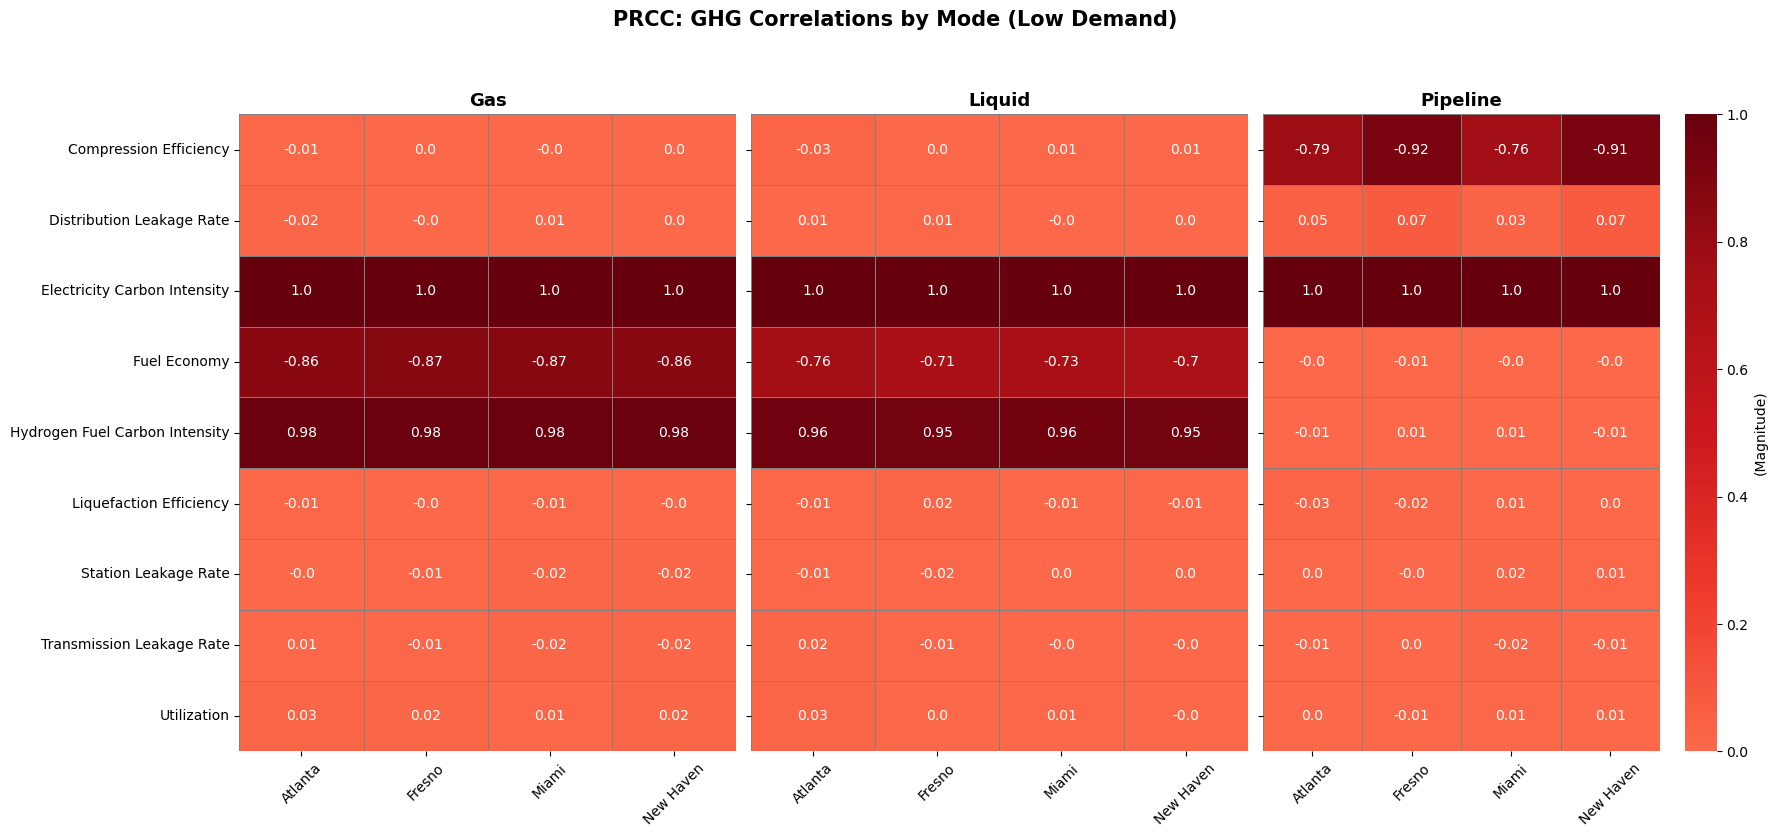

In [7]:
# ==============================================================
# COST & GHG HEATMAPS FOR ALL CORRELATION TYPES (LOW DEMAND)
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------------
# 1. Load and clean data
# --------------------------------------------------------------
file = "All Simulation Data/Low_Demand_Sensitivity_Analysis.csv"
df = pd.read_csv(file)

# Fix typos and duplicates
df["Variable"] = (
    df["Variable"]
    .str.replace("Commpression", "Compression", regex=False)
    .str.replace("_1", "", regex=False)
    .str.strip()
)

# Add absolute-value columns if missing
for metric in ["Pearson_r", "Spearman_r", "SRC", "PRCC"]:
    if f"abs_{metric}" not in df.columns:
        df[f"abs_{metric}"] = df[metric].abs()

# Split by output type
cost_df = df[df["Output"].str.contains("Total Cost", case=False, na=False)].copy()
ghg_df  = df[df["Output"].str.contains("Total GHG Cost", case=False, na=False)].copy()

# --------------------------------------------------------------
# 2. Define variables per mode
# --------------------------------------------------------------

# COST VARIABLES (economic / infrastructure)
cost_vars_gas = [
    "Electricity Cost", "Utilization", "Fuel Price",
    "Distribution Leakage Rate", 
    "Station Leakage Rate", "Transmission Leakage Rate",
     "Fuel Economy", "Cab Cost",
    "Liquefaction Capital Cost", "Compression Capital Cost",
    "Station Capital Cost", "Pipeline Capital Cost",
    "Liquefaction Efficiency", "Compression Efficiency"
]
cost_vars_liquid = cost_vars_gas.copy()
cost_vars_pipe = [
    "Electricity Cost", "Utilization",
    "Distribution Leakage Rate", "Station Leakage Rate",
    "Transmission Leakage Rate",  "Fuel Economy",
    "Cab Cost", "Compression Capital Cost",
    "Station Capital Cost", "Pipeline Capital Cost",
     "Compression Efficiency"
]

# GHG VARIABLES (environmental / emissions)
ghg_vars_gas = [
    "Hydrogen Fuel Carbon Intensity", "Electricity Carbon Intensity",
    "Utilization", "Distribution Leakage Rate",
    "Station Leakage Rate", "Transmission Leakage Rate",
    "Fuel Economy", "Compression Efficiency", "Liquefaction Efficiency"
]
ghg_vars_liquid = ghg_vars_gas.copy()
ghg_vars_pipe   = ghg_vars_gas.copy() + ["Distribution Leakage Rate"]

# --------------------------------------------------------------
# 3. Define unique variable orders per output type
# --------------------------------------------------------------
# Restrict to variables that are explicitly relevant
cost_var_order = sorted(list(set(cost_vars_gas + cost_vars_liquid + cost_vars_pipe)))
ghg_var_order  = sorted(list(set(ghg_vars_gas + ghg_vars_liquid + ghg_vars_pipe)))

# --------------------------------------------------------------
# 4. Pivot builder with NaN padding
# --------------------------------------------------------------
def make_pivot(sub, mode_name, valid_vars, full_index, metric):
    sub_mode = sub[sub["Mode"] == mode_name]
    if sub_mode.empty:
        return pd.DataFrame(index=full_index), pd.DataFrame(index=full_index)

    pivot_signed = sub_mode.pivot_table(
        index="Variable", columns="City", values=metric, aggfunc="mean"
    )

    # Restrict to variables that exist in this list
    pivot_signed = pivot_signed.reindex(full_index)
    pivot_signed.loc[~pivot_signed.index.isin(valid_vars), :] = np.nan

    # Color based on absolute correlation
    pivot_color = pivot_signed.abs()
    return pivot_signed, pivot_color

# --------------------------------------------------------------
# 5. Heatmap plotting function
# --------------------------------------------------------------
def plot_mode_heatmaps(pivots, mode_labels, cmap, title, metric):
    fig, axes = plt.subplots(1, len(pivots), figsize=(18, 8), sharey=True)

    for i, (ax, (pivot_signed, pivot_color), label) in enumerate(zip(axes, pivots, mode_labels)):
        sns.heatmap(
            pivot_color,
            cmap=cmap,
            center=0,
            annot=pivot_signed.round(2),
            fmt="",
            cbar=(i == len(pivots) - 1),
            ax=ax,
            cbar_kws={"label": f"(Magnitude)"},
            linewidths=0.4,
            linecolor="grey",
            vmin=0,
            vmax=1,
        )
        ax.set_title(label, fontsize=13, weight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", labelrotation=0)
        ax.set_facecolor("lightgrey")

    fig.suptitle(title, fontsize=15, weight="bold", y=1.04)
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------------
# 6. Generate plots for each metric and output type
# --------------------------------------------------------------
metrics = ["Pearson_r", "Spearman_r", "SRC", "PRCC"]

for metric in metrics:
    # COST HEATMAPS
    cost_pivots = [
        make_pivot(cost_df, "Gas Truck", cost_vars_gas, cost_var_order, metric),
        make_pivot(cost_df, "Liquid Truck", cost_vars_liquid, cost_var_order, metric),
        make_pivot(cost_df, "Pipeline", cost_vars_pipe, cost_var_order, metric),
    ]
    plot_mode_heatmaps(
        cost_pivots,
        ["Gas", "Liquid", "Pipeline"],
        cmap="Blues",
        title=f"{metric}: Cost Correlations by Mode (Low Demand)",
        metric=metric,
    )

    # GHG HEATMAPS
    ghg_pivots = [
        make_pivot(ghg_df, "Gas Truck", ghg_vars_gas, ghg_var_order, metric),
        make_pivot(ghg_df, "Liquid Truck", ghg_vars_liquid, ghg_var_order, metric),
        make_pivot(ghg_df, "Pipeline", ghg_vars_pipe, ghg_var_order, metric),
    ]
    plot_mode_heatmaps(
        ghg_pivots,
        ["Gas", "Liquid", "Pipeline"],
        cmap="Reds",
        title=f"{metric}: GHG Correlations by Mode (Low Demand)",
        metric=metric,
    )


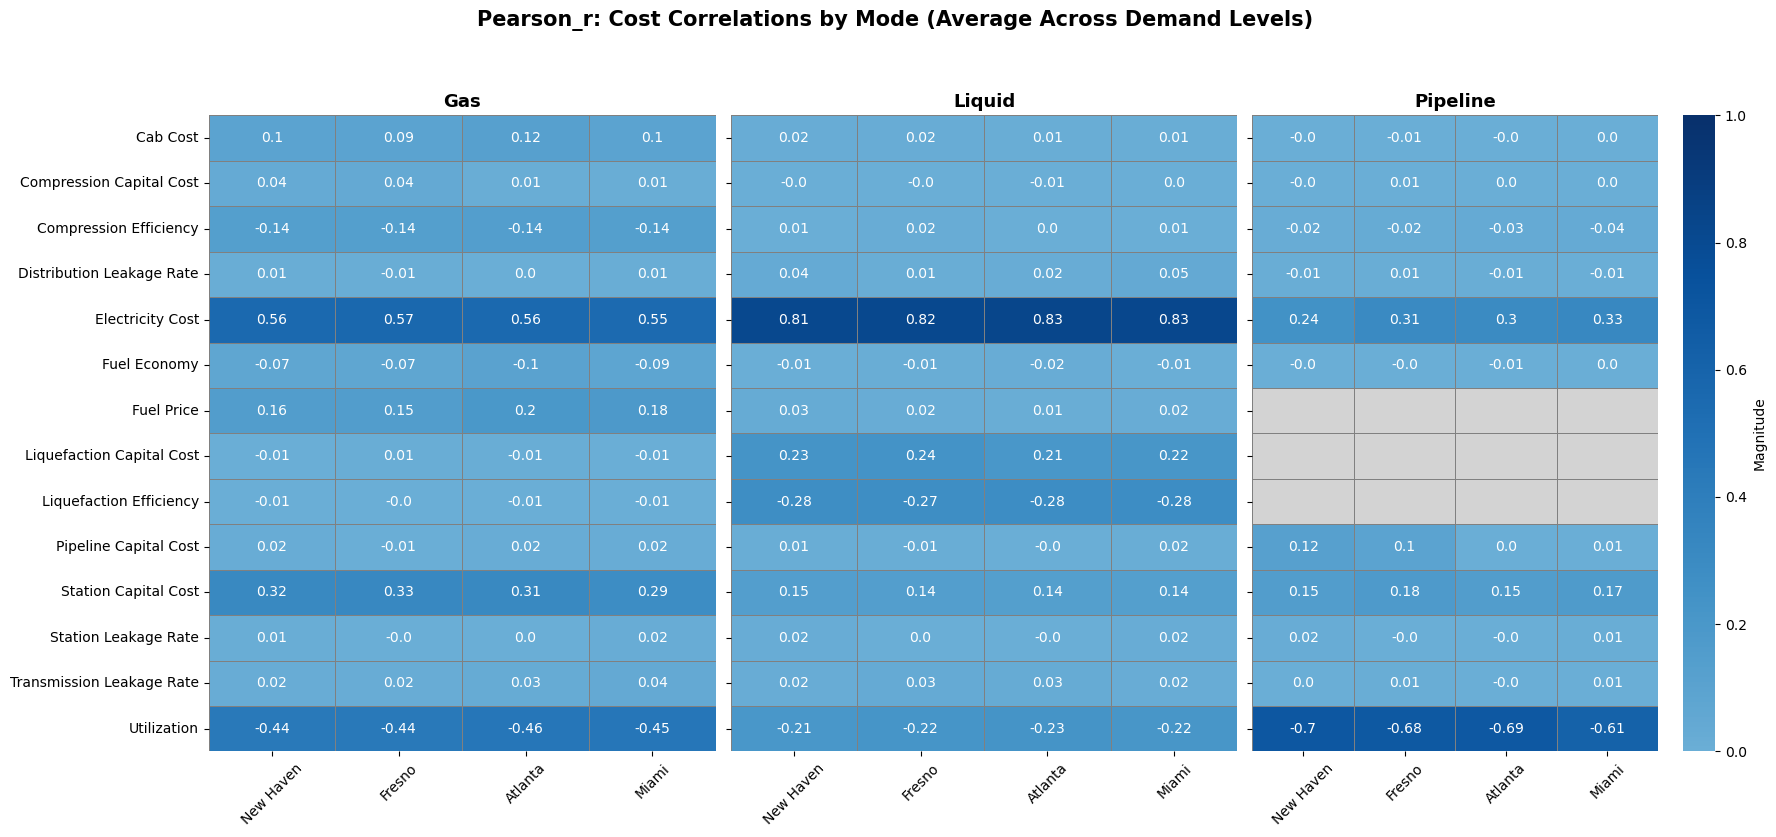

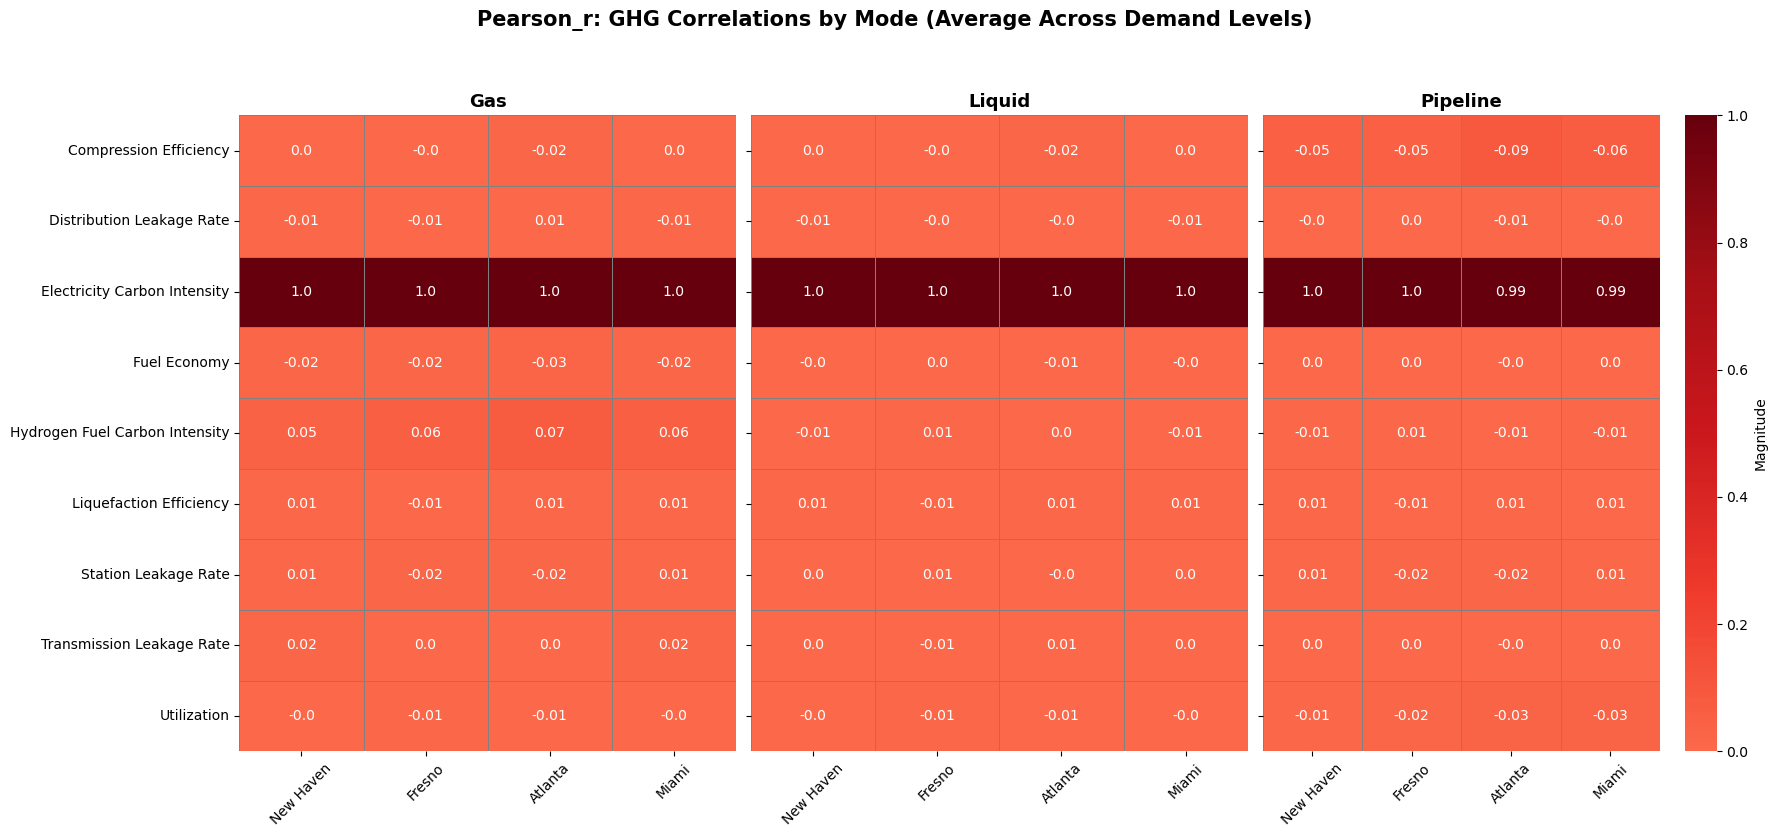

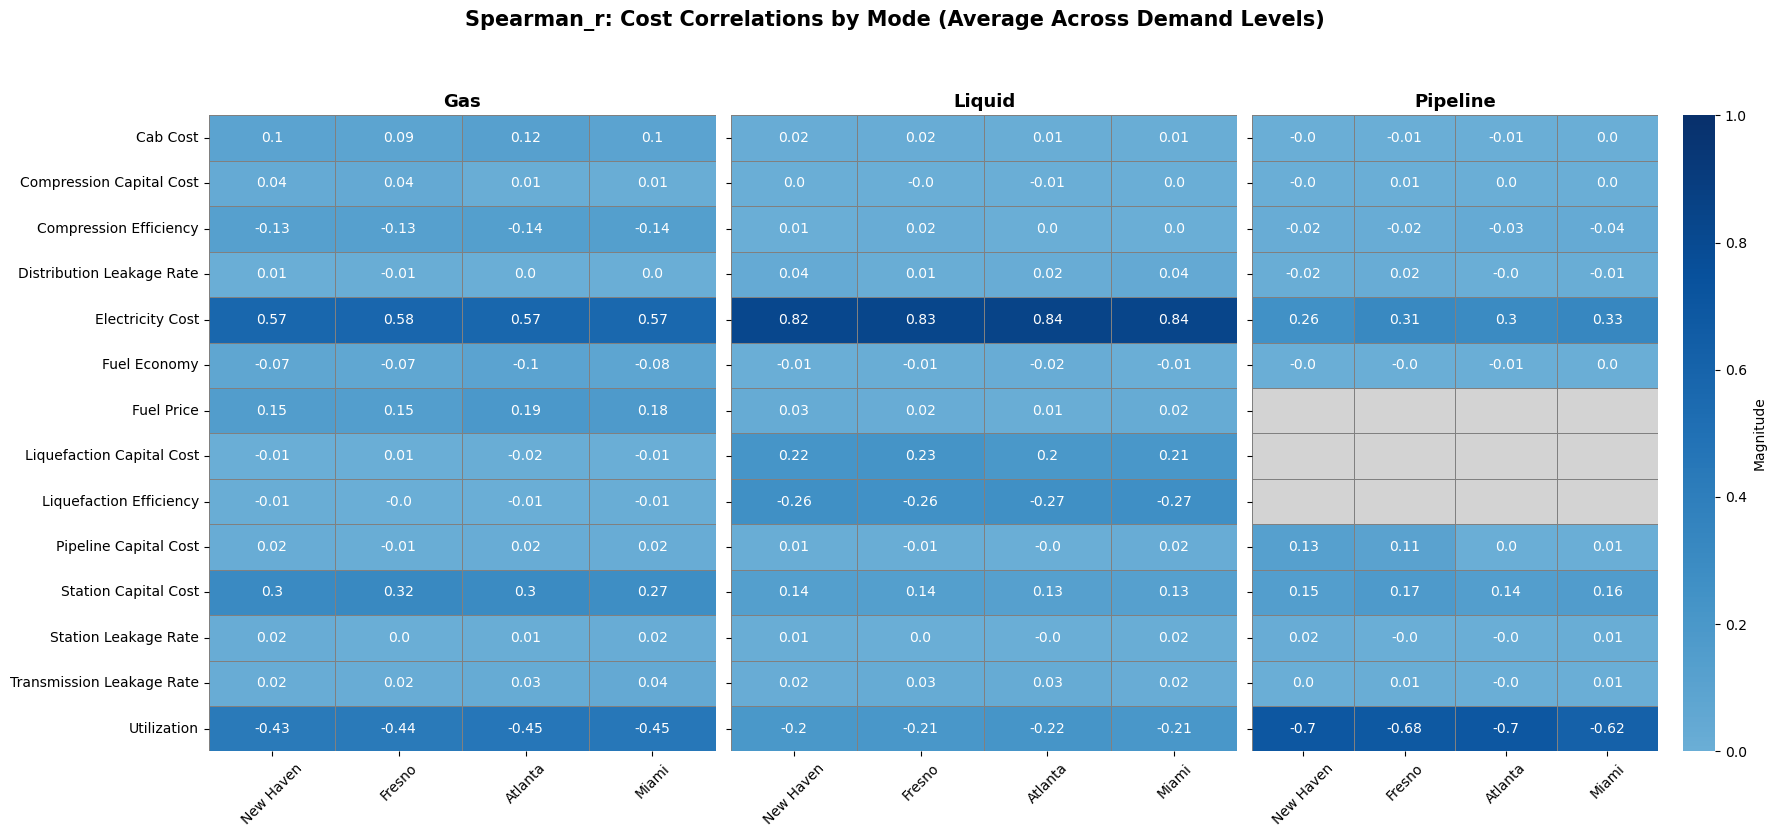

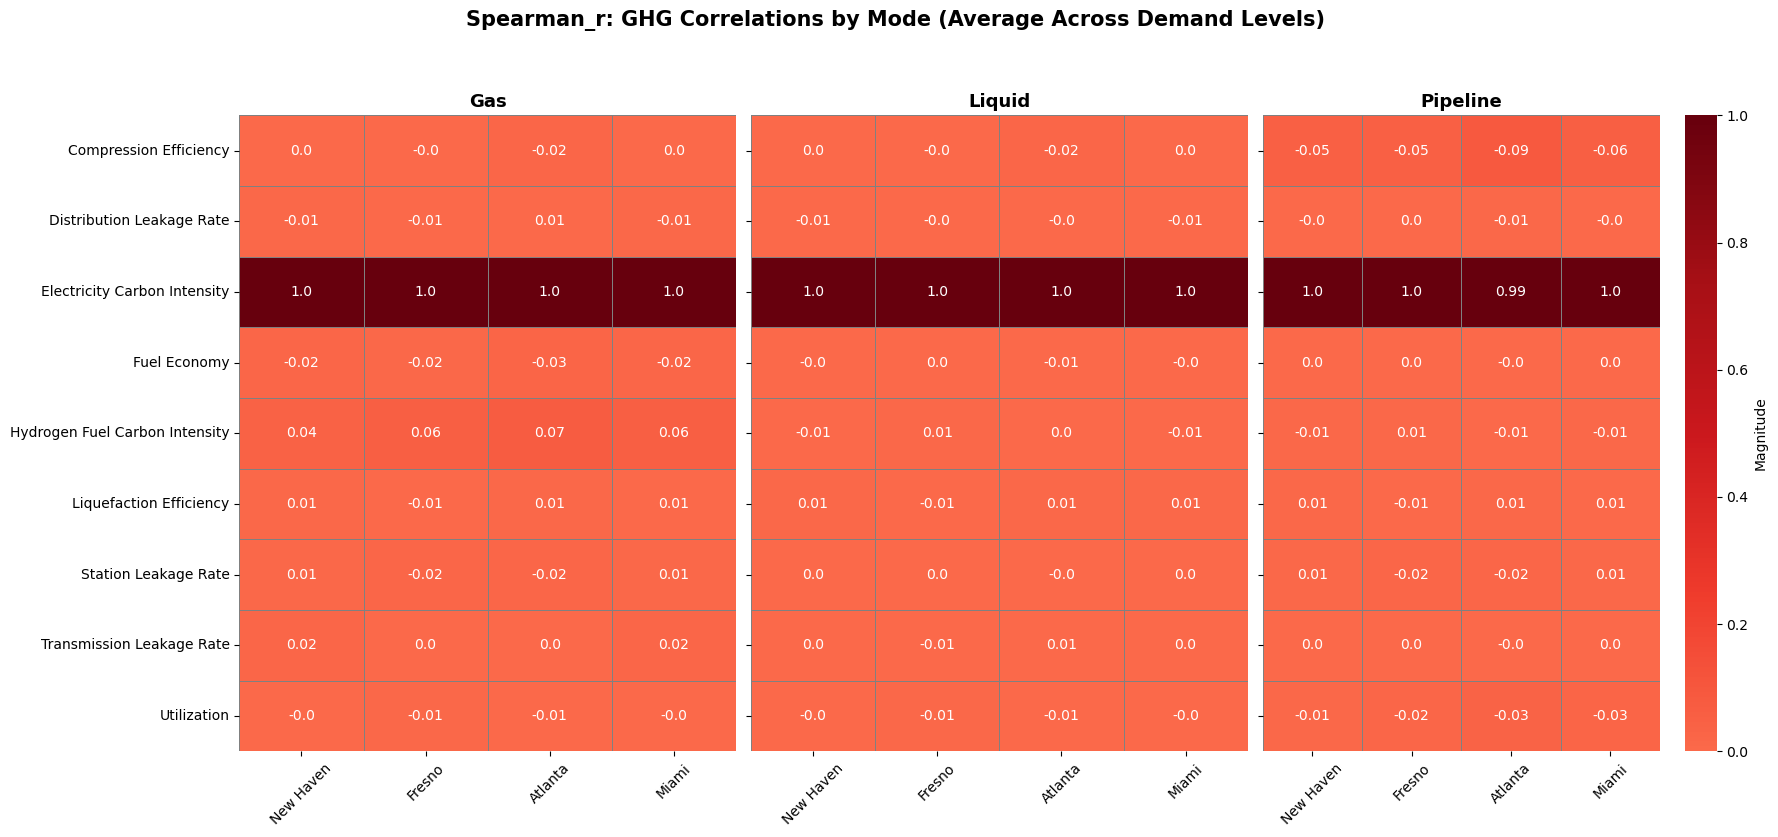

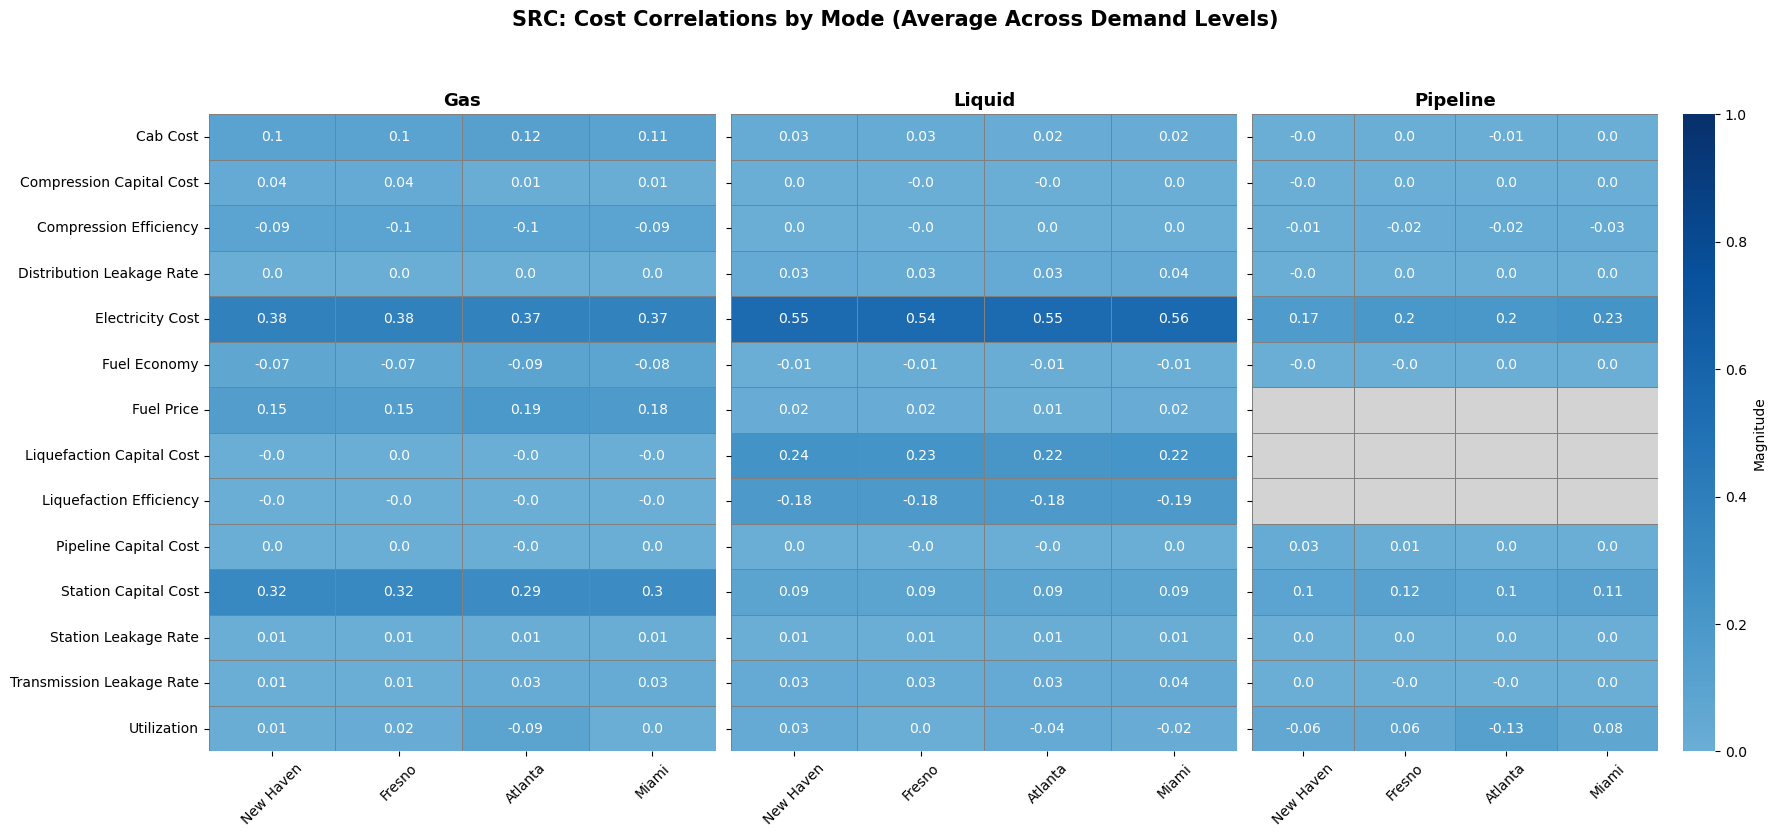

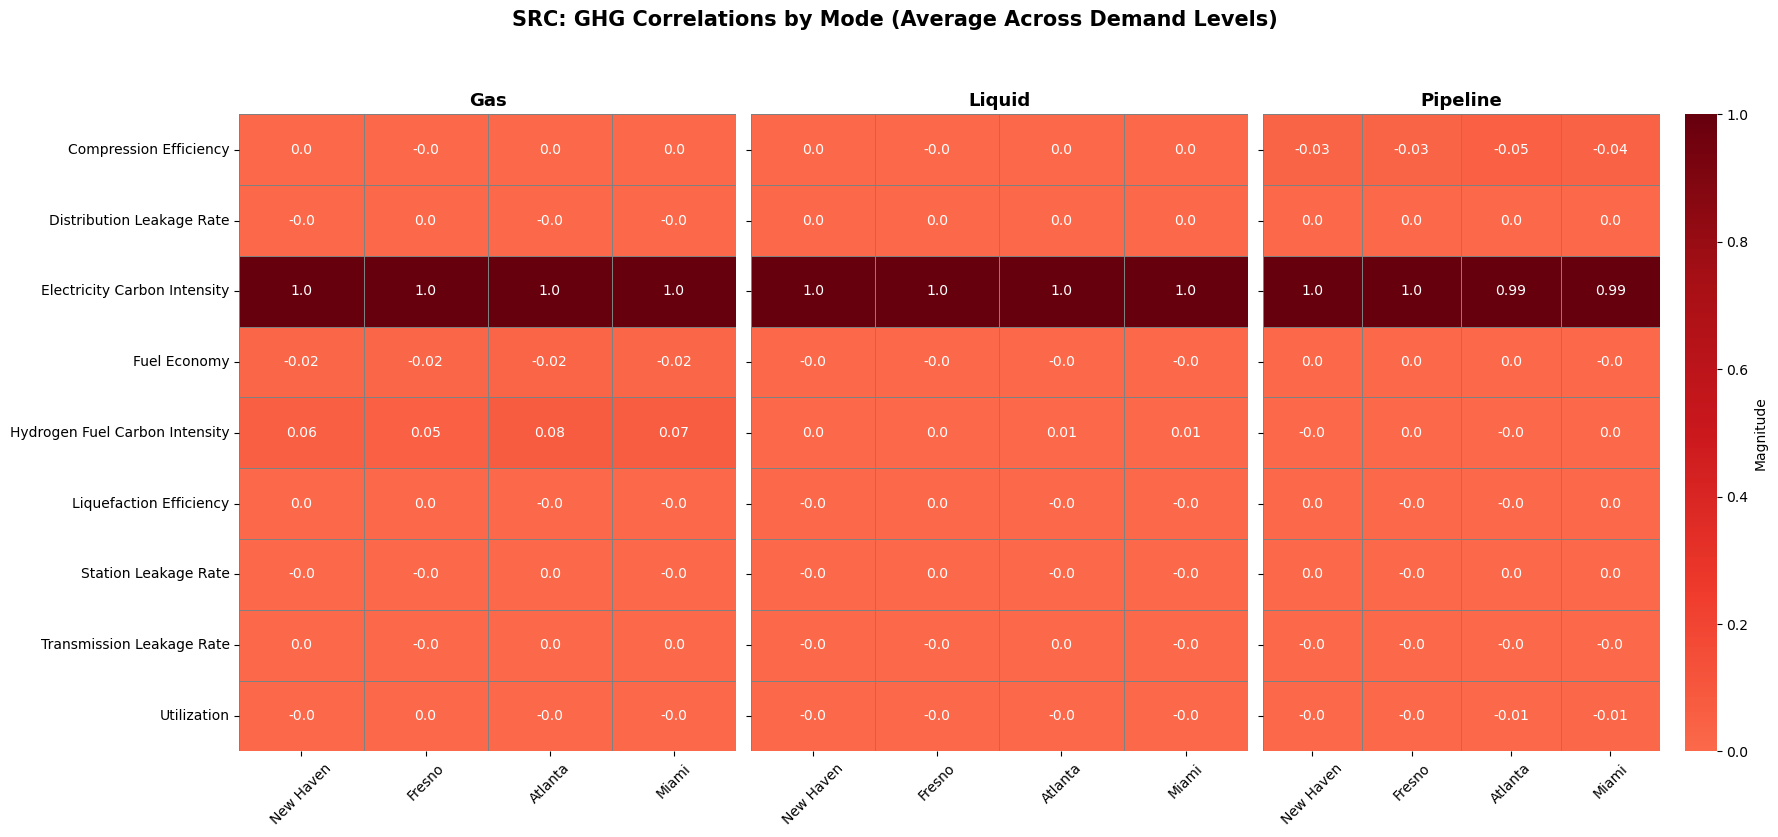

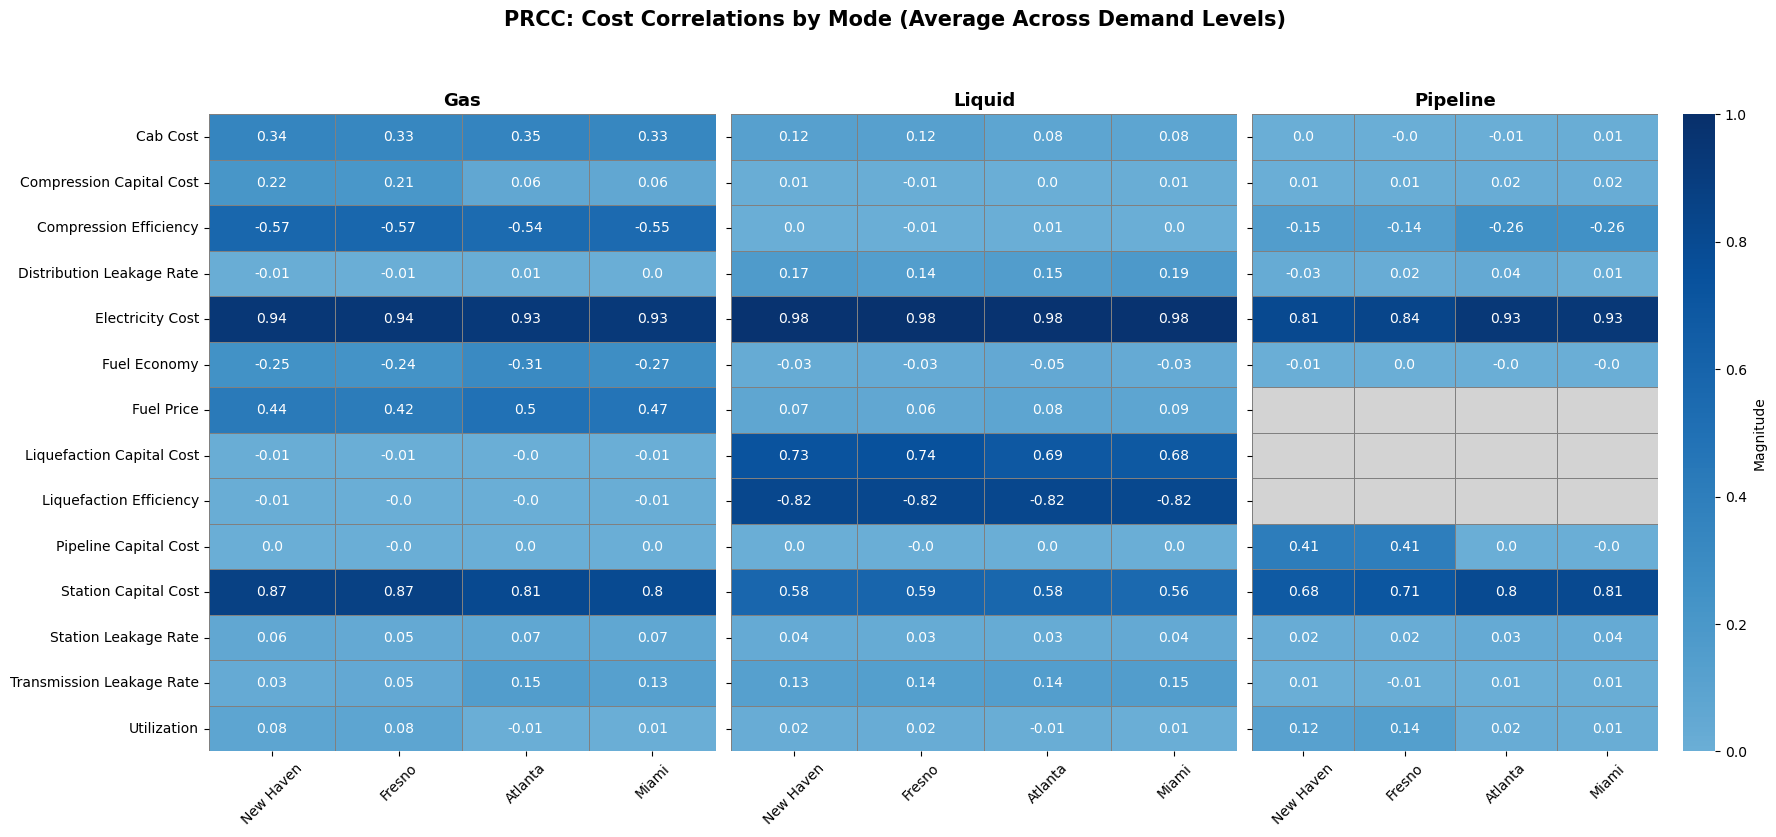

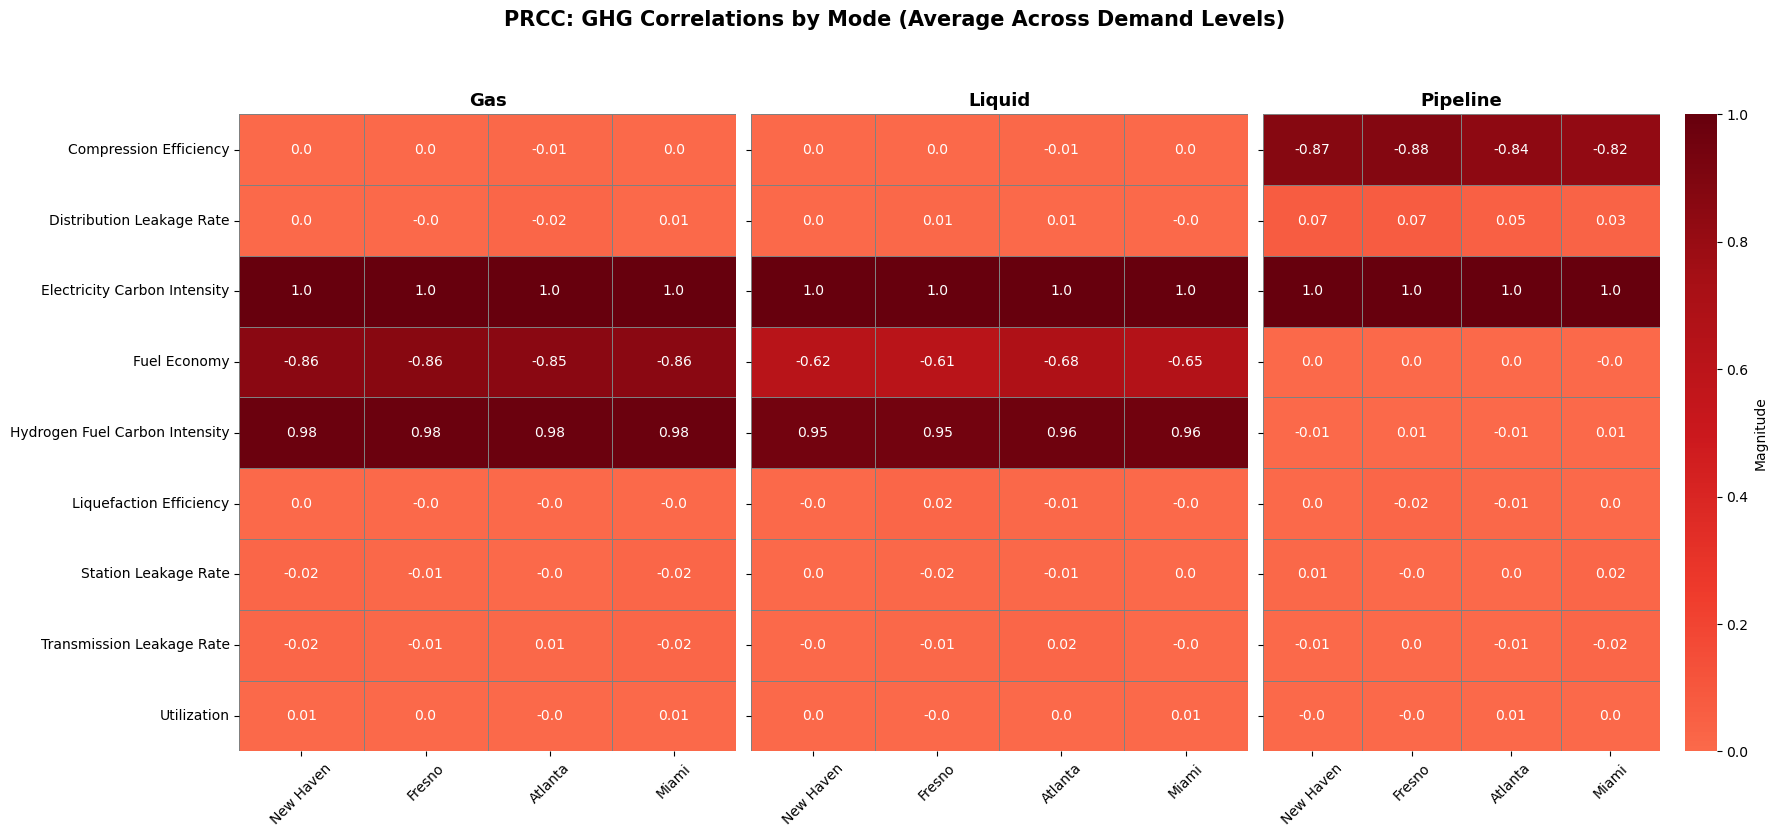

In [9]:
# ==============================================================
# COST & GHG HEATMAPS FOR ALL CORRELATION TYPES
# Averaged Across Low, Medium, and High Demand Scenarios
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --------------------------------------------------------------
# 1. Load and merge all demand scenarios
# --------------------------------------------------------------
output_folder = "Final Plots/"

files = {
    "Low": "All Simulation Data/Low_Demand_Sensitivity_Analysis.csv",
    "Medium": "All Simulation Data/Medium_Demand_Sensitivity_Analysis.csv",
    "High": "All Simulation Data/High_Demand_Sensitivity_Analysis.csv"
}

dfs = []
for label, path in files.items():
    temp = pd.read_csv(path)
    temp["Demand_Level"] = label
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

# --------------------------------------------------------------
# 2. Clean data and handle duplicates
# --------------------------------------------------------------
df["Variable"] = (
    df["Variable"]
    .str.replace("Commpression", "Compression", regex=False)
    .str.replace("_1", "", regex=False)
    .str.strip()
)

# Add abs columns if not already present
for metric in ["Pearson_r", "Spearman_r", "SRC", "PRCC"]:
    if f"abs_{metric}" not in df.columns:
        df[f"abs_{metric}"] = df[metric].abs()

# --------------------------------------------------------------
# 3. Average across demand levels
# --------------------------------------------------------------
df_avg = (
    df.groupby(["City", "Mode", "Output", "Variable"], as_index=False)
      .agg({
          "Pearson_r": "mean",
          "Spearman_r": "mean",
          "SRC": "mean",
          "PRCC": "mean"
      })
)

# Add absolute values again for plotting
for metric in ["Pearson_r", "Spearman_r", "SRC", "PRCC"]:
    df_avg[f"abs_{metric}"] = df_avg[metric].abs()

# --------------------------------------------------------------
# 4. Split by output type
# --------------------------------------------------------------
cost_df = df_avg[df_avg["Output"].str.contains("Total Cost", case=False, na=False)].copy()
ghg_df  = df_avg[df_avg["Output"].str.contains("Total GHG Cost", case=False, na=False)].copy()

# --------------------------------------------------------------
# 5. Define variable lists per mode
# --------------------------------------------------------------

# COST VARIABLES (economic / infrastructure)
cost_vars_gas = [
    "Electricity Cost", "Utilization", "Fuel Price",
    "Distribution Leakage Rate", 
    "Station Leakage Rate", "Transmission Leakage Rate",
    "Fuel Economy", "Cab Cost",
    "Liquefaction Capital Cost", "Compression Capital Cost",
    "Station Capital Cost", "Pipeline Capital Cost",
    "Liquefaction Efficiency", "Compression Efficiency"
]

cost_vars_liquid = cost_vars_gas.copy()
cost_vars_pipe = [
    "Electricity Cost", "Utilization",
    "Distribution Leakage Rate", "Station Leakage Rate",
    "Transmission Leakage Rate", "Fuel Economy",
    "Cab Cost", "Compression Capital Cost",
    "Station Capital Cost", "Pipeline Capital Cost",
    "Compression Efficiency"
]

# GHG VARIABLES (environmental / emissions)
ghg_vars_gas = [
    "Hydrogen Fuel Carbon Intensity", "Electricity Carbon Intensity",
    "Utilization", "Distribution Leakage Rate",
    "Station Leakage Rate", "Transmission Leakage Rate",
    "Fuel Economy", "Compression Efficiency", "Liquefaction Efficiency"
]
ghg_vars_liquid = ghg_vars_gas.copy()
ghg_vars_pipe   = ghg_vars_gas.copy() + ["Distribution Leakage Rate"]

# Define unique variable orders per output type
cost_var_order = sorted(list(set(cost_vars_gas + cost_vars_liquid + cost_vars_pipe)))
ghg_var_order  = sorted(list(set(ghg_vars_gas + ghg_vars_liquid + ghg_vars_pipe)))

# --------------------------------------------------------------
# 6. Pivot builder with NaN padding
# --------------------------------------------------------------
def make_pivot(sub, mode_name, valid_vars, full_index, metric):
    sub_mode = sub[sub["Mode"] == mode_name]
    if sub_mode.empty:
        return pd.DataFrame(index=full_index), pd.DataFrame(index=full_index)
    # ✅ Define your custom city order here
    city_order = ["New Haven", "Fresno", "Atlanta", "Miami"]
    
    pivot_signed = sub_mode.pivot_table(
        index="Variable", columns="City", values=metric, aggfunc="mean"
    )

    # Restrict to variables that exist in this mode
    pivot_signed = pivot_signed.reindex(columns = city_order)
    pivot_signed = pivot_signed.reindex(full_index)
    
    pivot_signed.loc[~pivot_signed.index.isin(valid_vars), :] = np.nan

    # Color based on absolute correlation (magnitude)
    pivot_color = pivot_signed.abs()
    return pivot_signed, pivot_color

# --------------------------------------------------------------
# 7. Heatmap plotting function
# --------------------------------------------------------------
def plot_mode_heatmaps(pivots, mode_labels, cmap, title, metric, savepath):
    fig, axes = plt.subplots(1, len(pivots), figsize=(18, 8), sharey=True)

    for i, (ax, (pivot_signed, pivot_color), label) in enumerate(zip(axes, pivots, mode_labels)):
        sns.heatmap(
            pivot_color,
            cmap=cmap,
            center=0,
            annot=pivot_signed.round(2),
            fmt="",
            cbar=(i == len(pivots) - 1),
            ax=ax,
            cbar_kws={"label": f"Magnitude"},
            linewidths=0.4,
            linecolor="grey",
            vmin=0,
            vmax=1,
        )
        ax.set_title(label, fontsize=13, weight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", labelrotation=0)
        ax.set_facecolor("lightgrey")

    fig.suptitle(title, fontsize=15, weight="bold", y=1.04)
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

# --------------------------------------------------------------
# 8. Generate plots for each metric and output type
# --------------------------------------------------------------
metrics = ["Pearson_r", "Spearman_r", "SRC", "PRCC"]

for metric in metrics:
    # COST HEATMAPS
    cost_pivots = [
        make_pivot(cost_df, "Gas Truck", cost_vars_gas, cost_var_order, metric),
        make_pivot(cost_df, "Liquid Truck", cost_vars_liquid, cost_var_order, metric),
        make_pivot(cost_df, "Pipeline", cost_vars_pipe, cost_var_order, metric),
    ]

    cost_title = f"{metric}: Cost Correlations by Mode (Average Across Demand Levels)"
    cost_path = os.path.join(output_folder, f"{metric}_Cost.png")
    
    plot_mode_heatmaps(
        cost_pivots,
        ["Gas", "Liquid", "Pipeline"],
        cmap="Blues",
        title=f"{metric}: Cost Correlations by Mode (Average Across Demand Levels)",
        metric=metric,
        savepath=cost_path
    )

    # GHG HEATMAPS
    ghg_pivots = [
        make_pivot(ghg_df, "Gas Truck", ghg_vars_gas, ghg_var_order, metric),
        make_pivot(ghg_df, "Liquid Truck", ghg_vars_liquid, ghg_var_order, metric),
        make_pivot(ghg_df, "Pipeline", ghg_vars_pipe, ghg_var_order, metric),
    ]

    ghg_title = f"{metric}: GHG Correlations by Mode (Average Across Demand Levels)"
    ghg_path = os.path.join(output_folder, f"{metric}_GHG.png")
    
    plot_mode_heatmaps(
        ghg_pivots,
        ["Gas", "Liquid", "Pipeline"],
        cmap="Reds",
        title=f"{metric}: GHG Correlations by Mode (Average Across Demand Levels)",
        metric=metric,
        savepath=ghg_path
    )
